In [8]:
from google.colab import files
upload = files.upload()


Saving q1_heart_disease.csv to q1_heart_disease.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [14]:
df = pd.read_csv("q1_heart_disease.csv")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


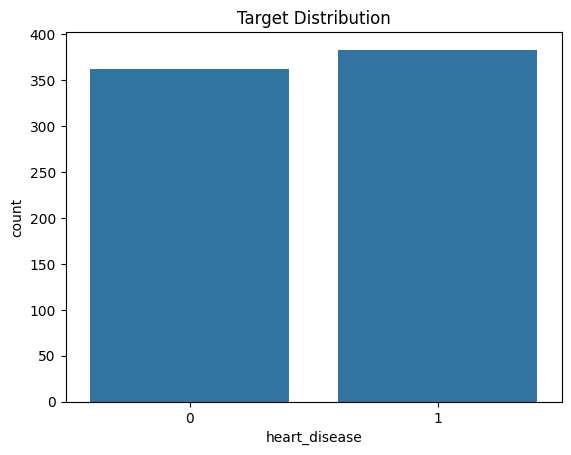

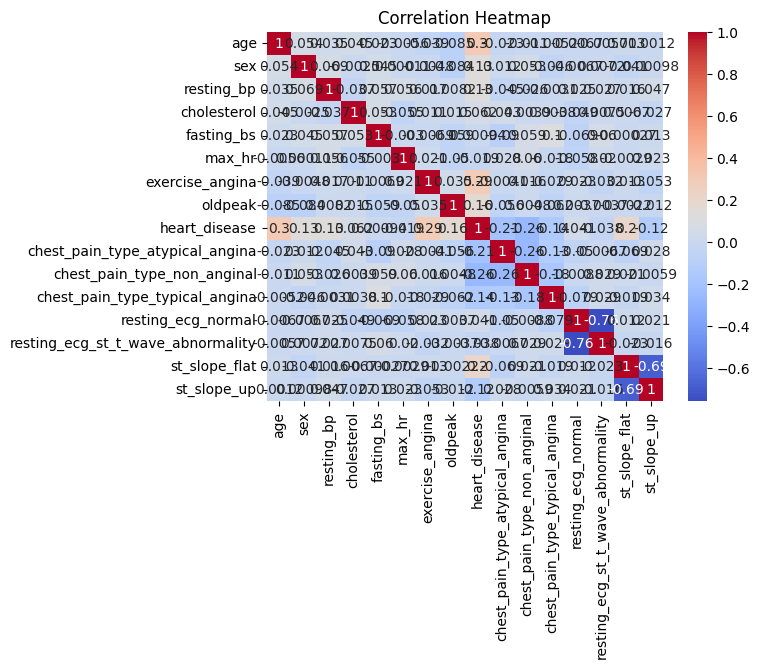

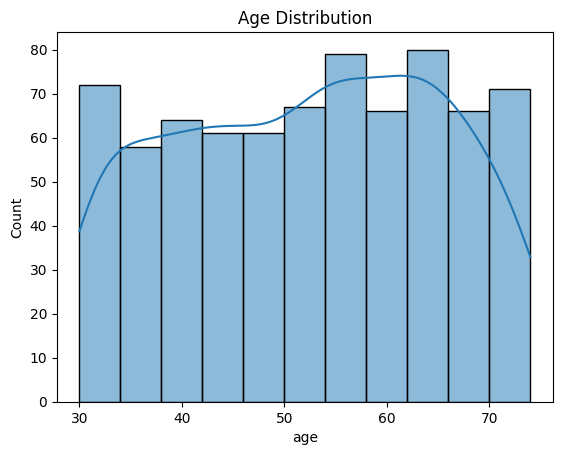

In [20]:
plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [22]:
df = df.dropna()

categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=42
)


In [23]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    results[name] = model


Decision Tree
[[50 22]
 [23 54]]
              precision    recall  f1-score   support

           0       0.68      0.69      0.69        72
           1       0.71      0.70      0.71        77

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149


Random Forest
[[56 16]
 [13 64]]
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        72
           1       0.80      0.83      0.82        77

    accuracy                           0.81       149
   macro avg       0.81      0.80      0.80       149
weighted avg       0.81      0.81      0.81       149


Gradient Boosting
[[57 15]
 [15 62]]
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        72
           1       0.81      0.81      0.81        77

    accuracy                           0.80       149
   macro avg       0.8

In [24]:
best_model = results["Random Forest"]


In [25]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)

best_tuned = grid.best_estimator_
y_pred = best_tuned.predict(X_test)

print("\nTuned Model Performance")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best Params: {'max_depth': 5, 'n_estimators': 50}

Tuned Model Performance
[[55 17]
 [17 60]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        72
           1       0.78      0.78      0.78        77

    accuracy                           0.77       149
   macro avg       0.77      0.77      0.77       149
weighted avg       0.77      0.77      0.77       149



Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Head:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.

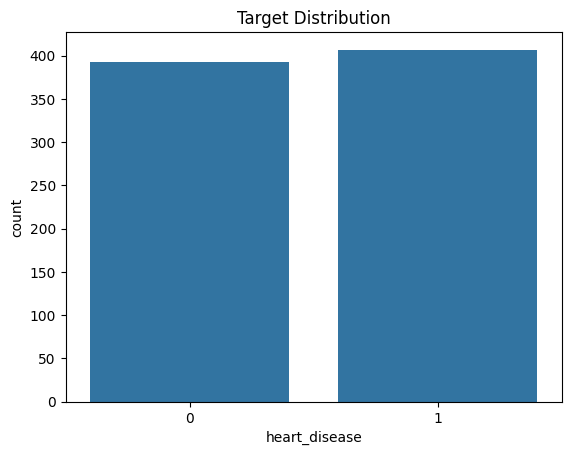

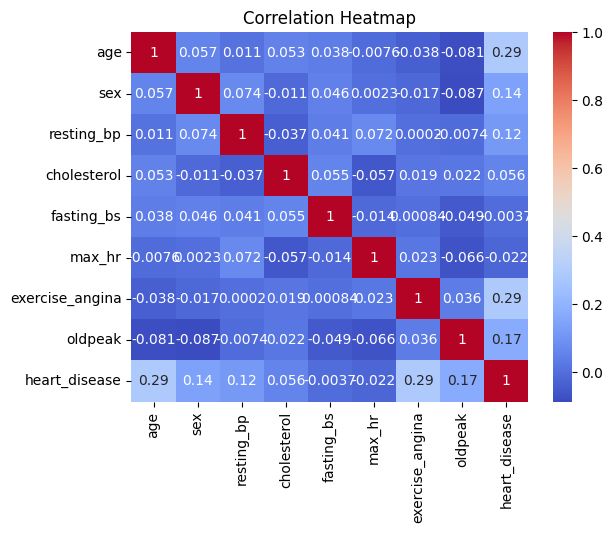

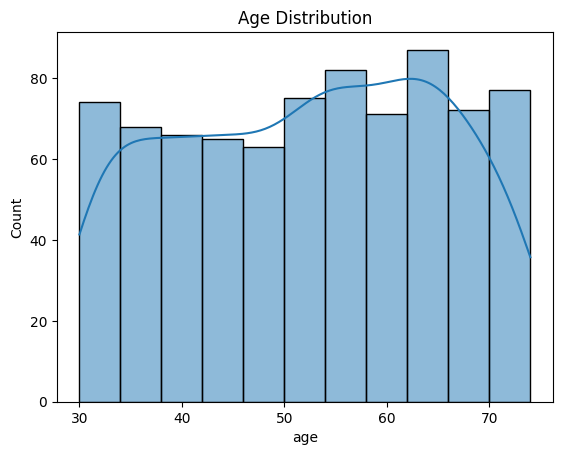


Decision Tree
[[50 22]
 [23 54]]
              precision    recall  f1-score   support

           0       0.68      0.69      0.69        72
           1       0.71      0.70      0.71        77

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149


Random Forest
[[56 16]
 [13 64]]
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        72
           1       0.80      0.83      0.82        77

    accuracy                           0.81       149
   macro avg       0.81      0.80      0.80       149
weighted avg       0.81      0.81      0.81       149


Gradient Boosting
[[57 15]
 [15 62]]
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        72
           1       0.81      0.81      0.81        77

    accuracy                           0.80       149
   macro avg       0.8

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


df = pd.read_csv('q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nHead:\n", df.head())


plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


df = df.dropna()

categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=42
)


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    results[name] = model


best_model = results["Random Forest"]


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)

best_tuned = grid.best_estimator_
y_pred = best_tuned.predict(X_test)

print("\nTuned Model Performance")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))